#Práctica 5: **Análisis de sobreajuste y subajuste mediante regresión Kvecinos más cercanos KNN en Python**


Integrantes:

*   Aguirre Lanto Victor Manuel
*   Gasca Fragoso Pedro
*   Guevara Badillo Areli Alejandra
*   Montiel Toro Arael de Jesús
*   Ramirez Lozano Gael Martin



#Carga del archivo carros.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

carros = pd.read_csv('carros.csv')

carros.head()


Saving carros.csv to carros.csv


,kms,precio
0,6048,1385956
1,11825,1297582
2,20000,1000000
3,21048,1284844
4,21549,685300


#Gráfica de dispersión de los datos

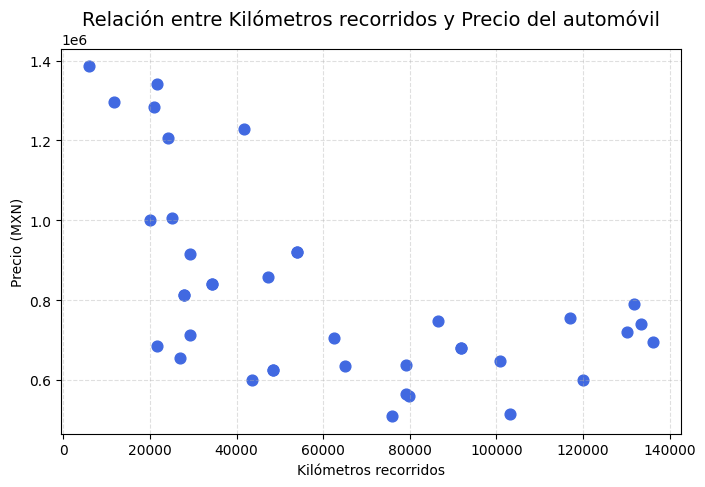

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(carros["kms"], carros["precio"], color="royalblue", s=60)
plt.title("Relación entre Kilómetros recorridos y Precio del automóvil", fontsize=14)
plt.xlabel("Kilómetros recorridos")
plt.ylabel("Precio (MXN)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


#División del conjunto de datos en entrenamiento y prueba

In [ ]:
from sklearn.model_selection import train_test_split

# Variable independiente (kms) y dependiente (precio)
X = carros[["kms"]]
y = carros["precio"]

# División 80% - 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Mostrar tamaños resultantes
print("Tamaño del conjunto de entrenamiento:", len(X_train))
print("Tamaño del conjunto de prueba:", len(X_test))


Tamaño del conjunto de entrenamiento: 31
Tamaño del conjunto de prueba: 8


#Entrenamiento del modelo KNN para distintos valores de K

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor

# Escalado de los datos (normalización al rango 0–1)
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

# Ajustar el escalador con los datos de entrenamiento
X_train_scaled = scaler_x.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

# Definición de los valores de K a evaluar
valores_k = [1, 3, 5, 10, 15, 20]
print("Valores de K definidos para el modelo:", valores_k)


Valores de K definidos para el modelo: [1, 3, 5, 10, 15, 20]


#Gráfica de los resultados obtenidos para cada valor de K

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


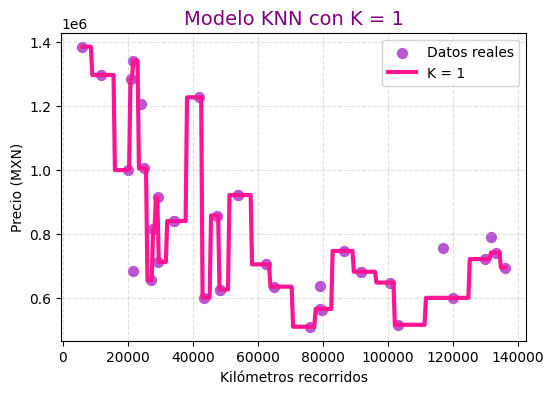

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


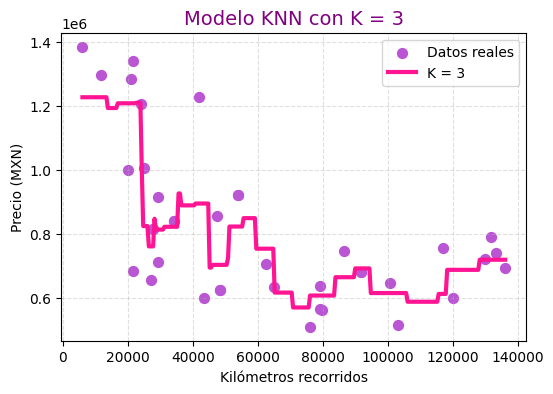

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


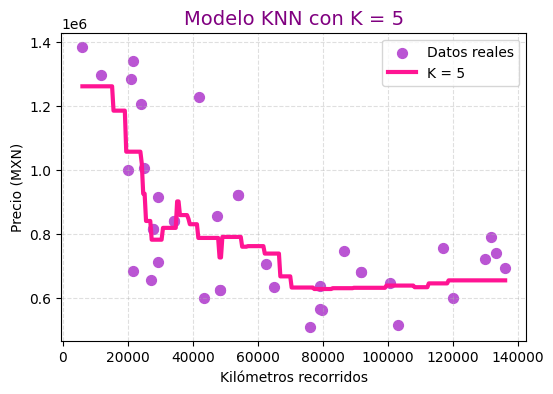

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


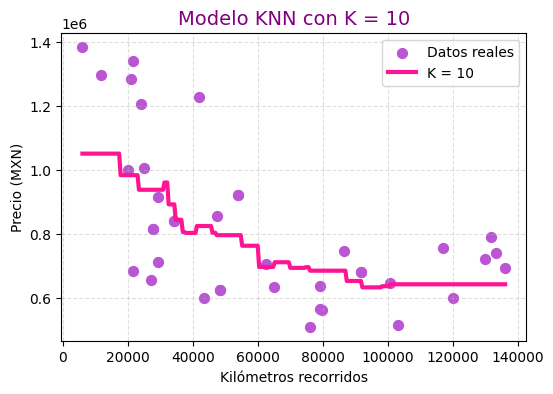

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


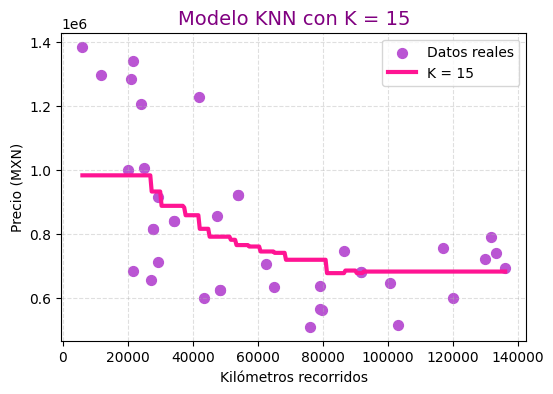

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


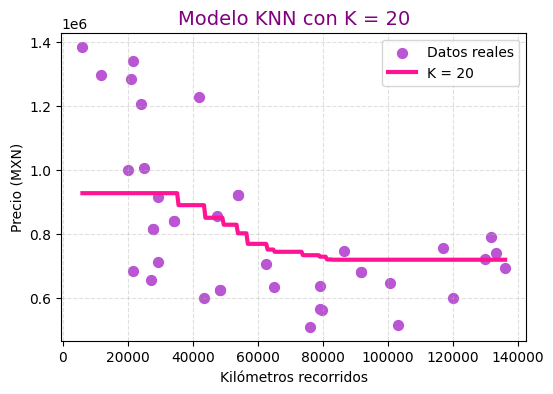

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Crear un rango de valores de kilómetros para graficar la predicción continua
kms_rango = np.linspace(X["kms"].min(), X["kms"].max(), 300).reshape(-1, 1)

# Entrenar y graficar un modelo KNN para cada valor de K
for k in valores_k:
    modelo = KNeighborsRegressor(n_neighbors=k)
    modelo.fit(X_train_scaled, y_train_scaled)

    # Generar predicciones
    kms_rango_scaled = scaler_x.transform(kms_rango)
    pred_scaled = modelo.predict(kms_rango_scaled)
    pred = scaler_y.inverse_transform(pred_scaled)

    # Crear gráfica
    plt.figure(figsize=(6,4))
    plt.scatter(X, y, color="mediumorchid", s=50, label="Datos reales")
    plt.plot(kms_rango, pred, color="deeppink", linewidth=3, label=f"K = {k}")

    plt.title(f"Modelo KNN con K = {k}", fontsize=14, color="purple")
    plt.xlabel("Kilómetros recorridos")
    plt.ylabel("Precio (MXN)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()


#Personalización de colores y estilos de las gráficas

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


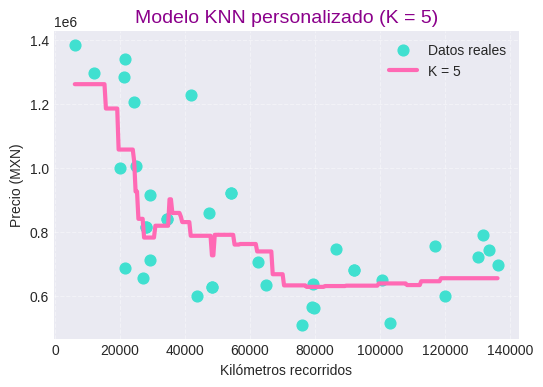

In [ ]:
# Aplicar un estilo de fondo general
plt.style.use('seaborn-v0_8-darkgrid')

# Colores personalizados
color_puntos = "turquoise"   # Color de los puntos (datos reales)
color_linea = "hotpink"      # Color de la línea del modelo

# Repetir la gráfica con los nuevos estilos
kms_rango = np.linspace(X["kms"].min(), X["kms"].max(), 300).reshape(-1, 1)

k = 5  # ejemplo con K=5, puedes cambiarlo
modelo = KNeighborsRegressor(n_neighbors=k)
modelo.fit(X_train_scaled, y_train_scaled)

kms_rango_scaled = scaler_x.transform(kms_rango)
pred_scaled = modelo.predict(kms_rango_scaled)
pred = scaler_y.inverse_transform(pred_scaled)

plt.figure(figsize=(6,4))
plt.scatter(X, y, color=color_puntos, s=60, label="Datos reales")
plt.plot(kms_rango, pred, color=color_linea, linewidth=3, label=f"K = {k}")
plt.title(f"Modelo KNN personalizado (K = {k})", fontsize=14, color="darkmagenta")
plt.xlabel("Kilómetros recorridos")
plt.ylabel("Precio (MXN)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


#Generación de las 39 gráficas

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


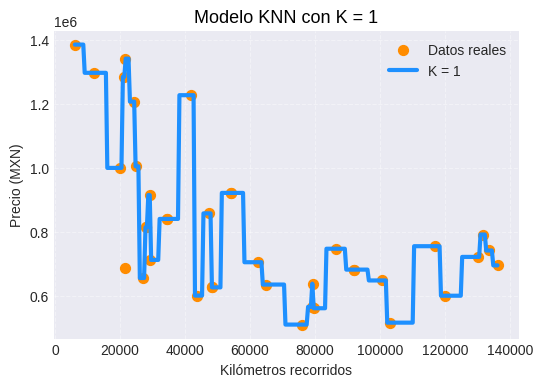

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


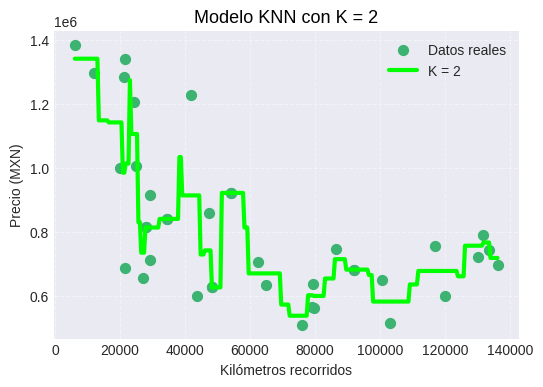

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


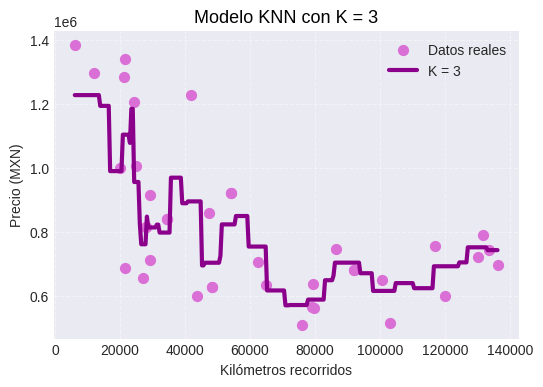

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


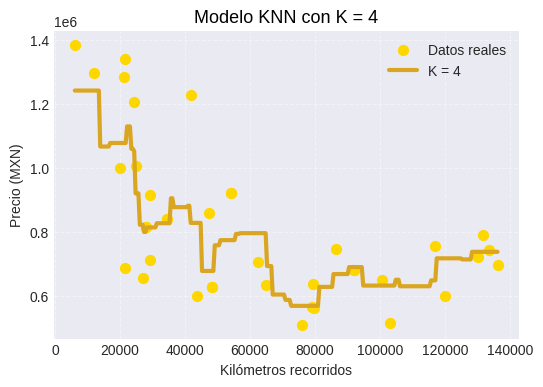

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


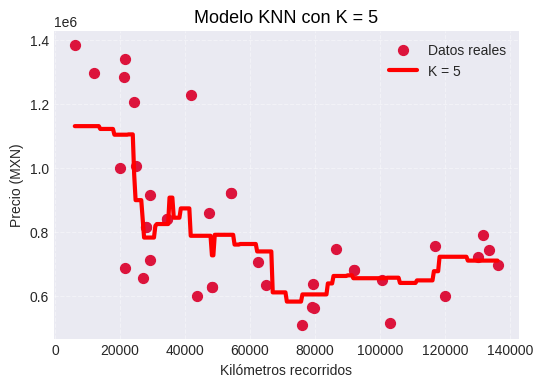

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


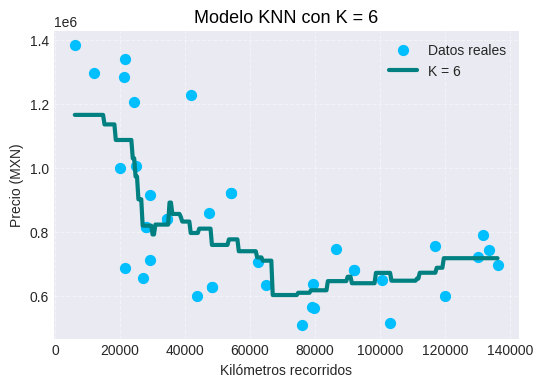

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


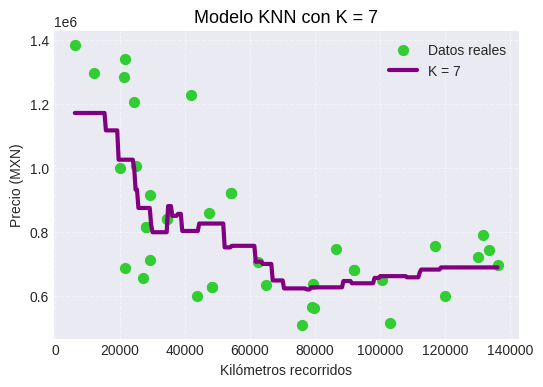

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


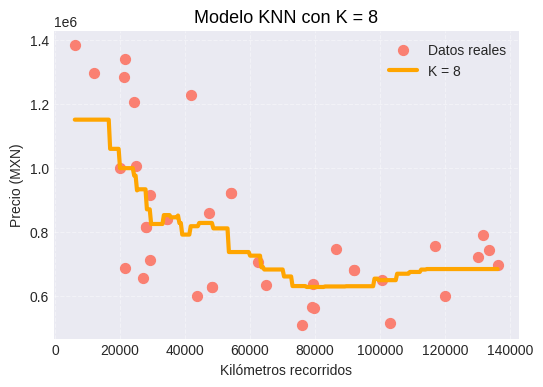

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


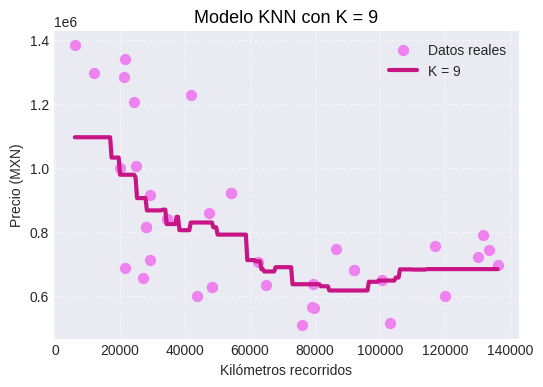

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


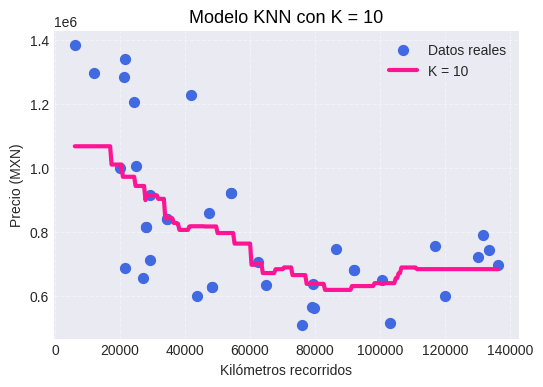

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


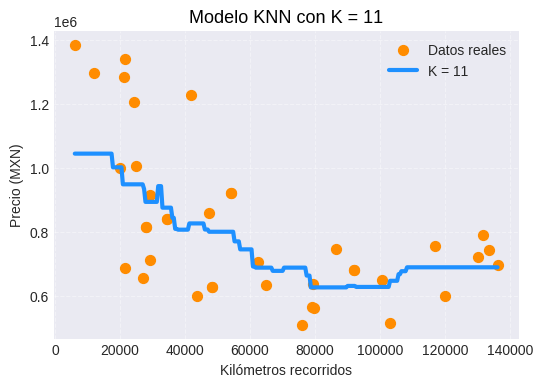

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


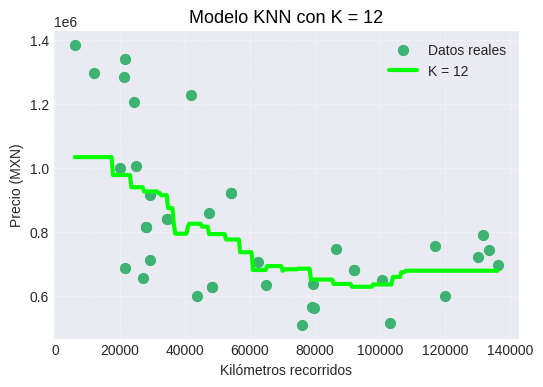

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


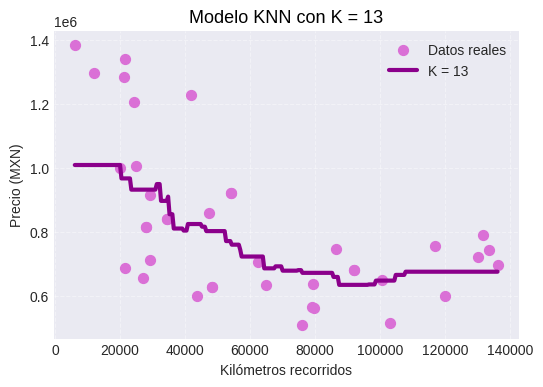

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


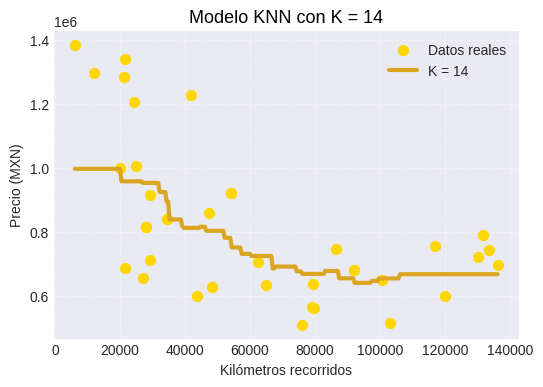

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


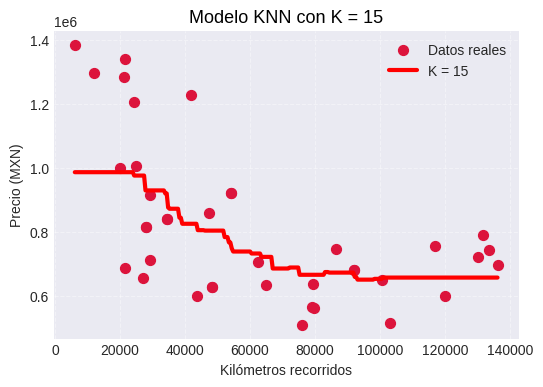

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


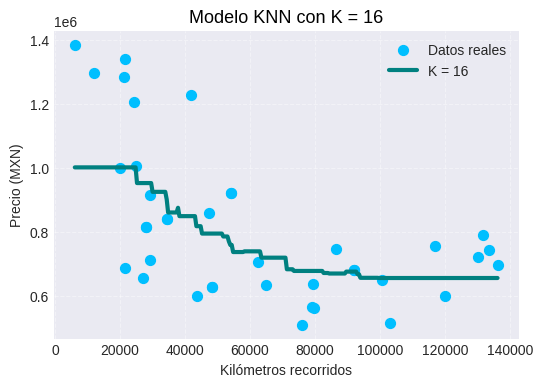

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


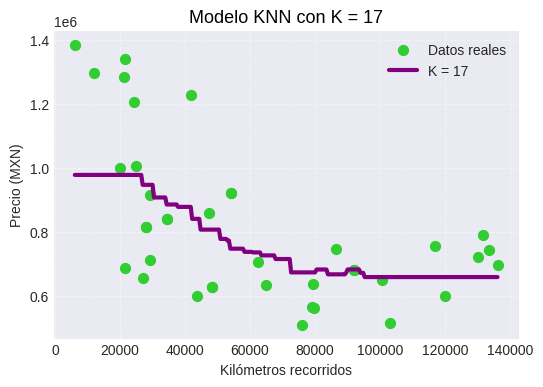

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


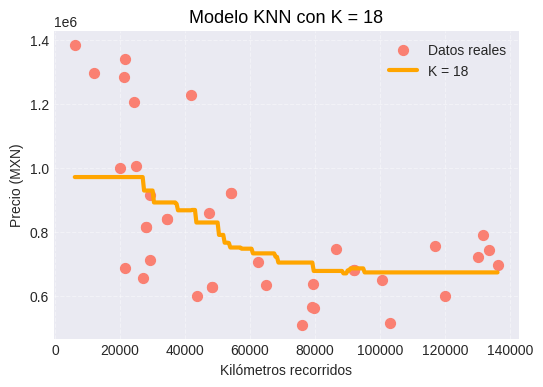

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


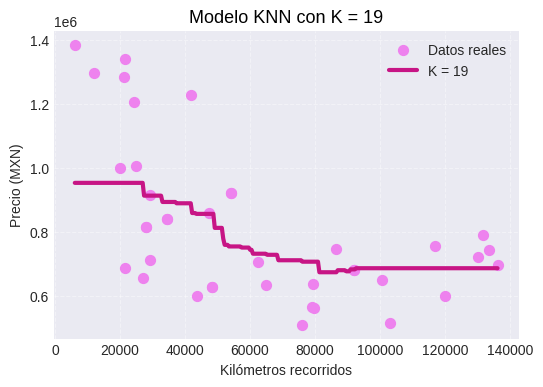

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


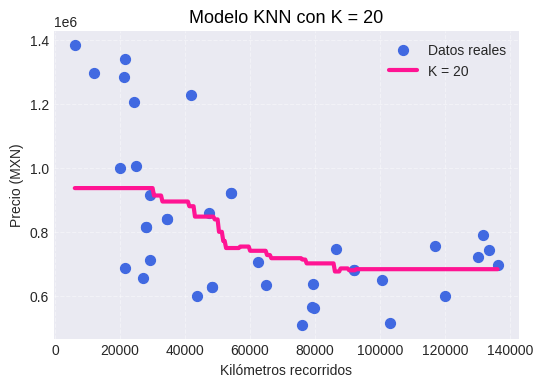

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


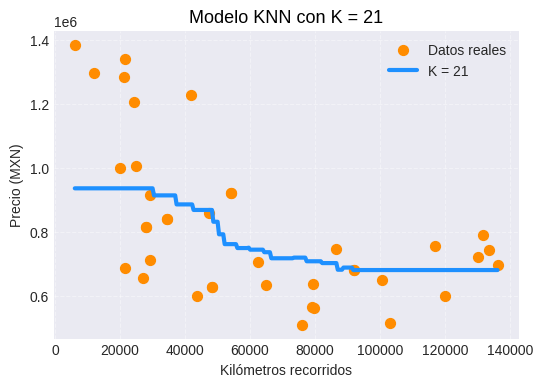

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


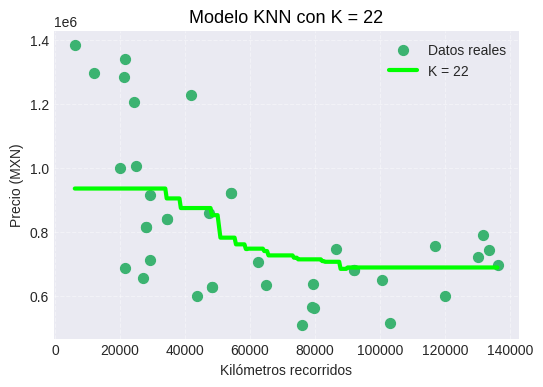

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


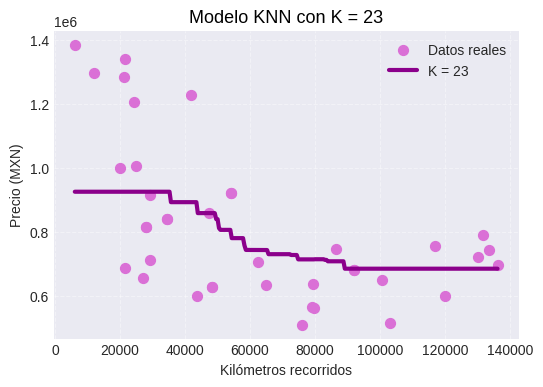

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


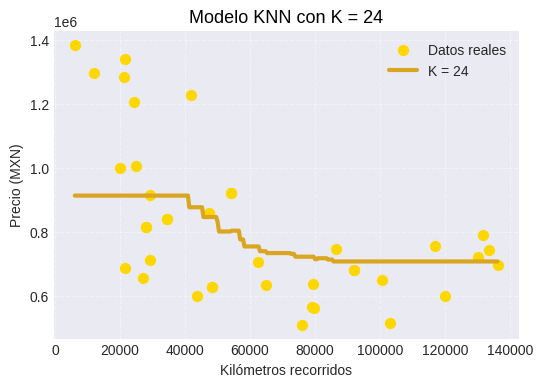

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


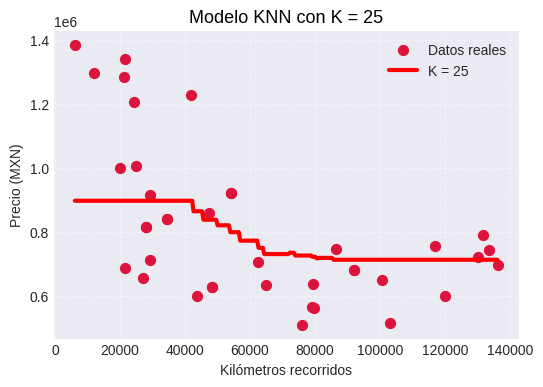

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


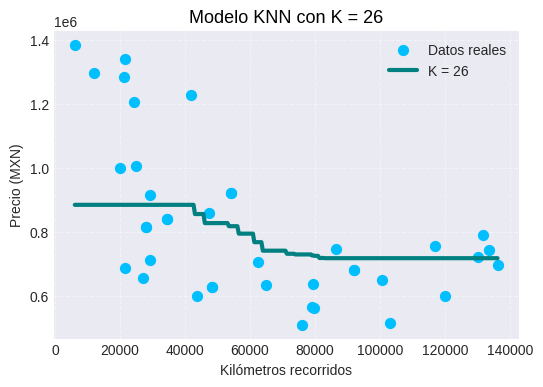

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


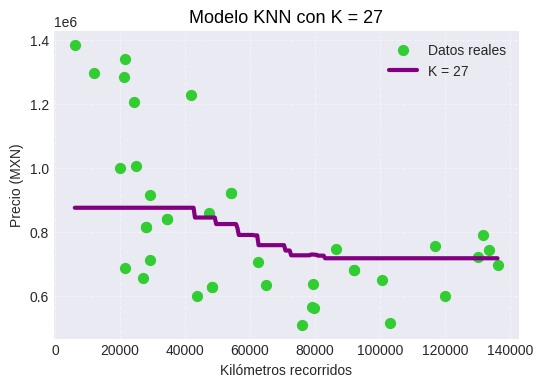

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


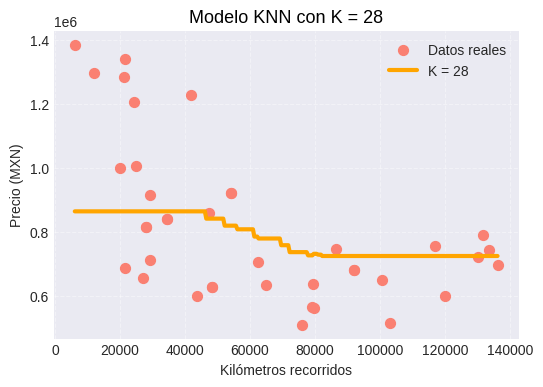

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


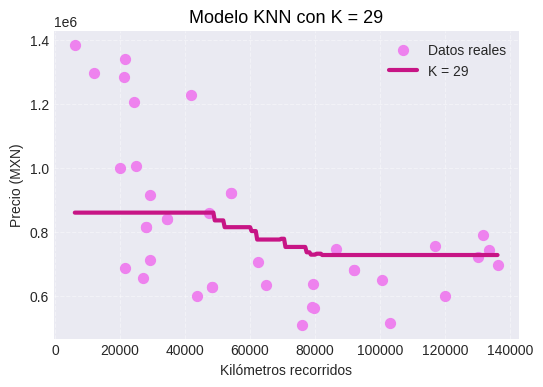

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


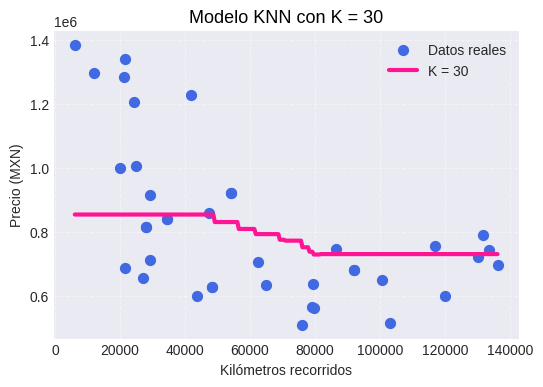

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


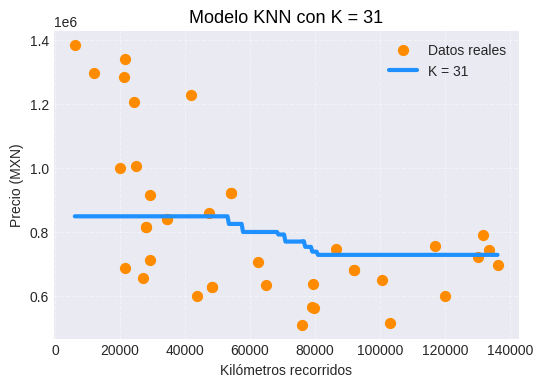

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


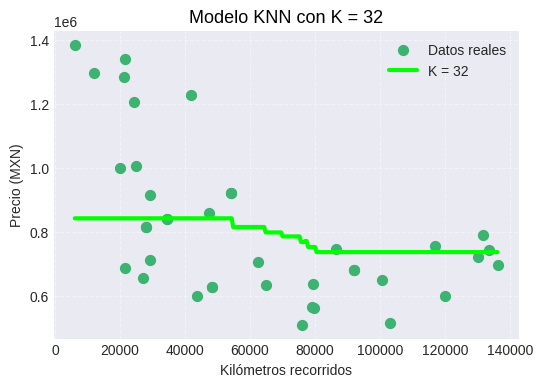

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


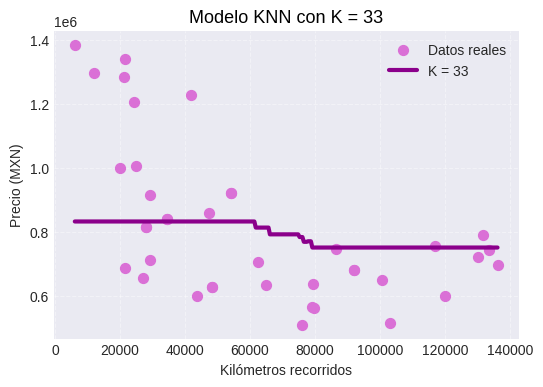

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


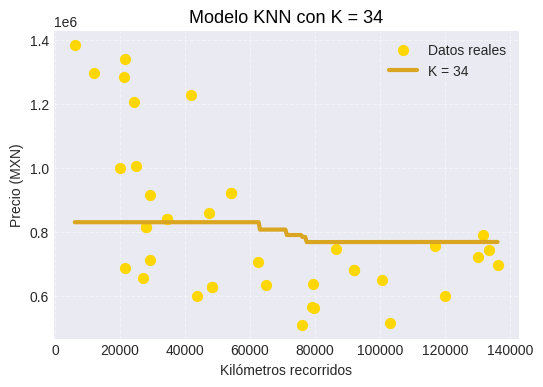

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


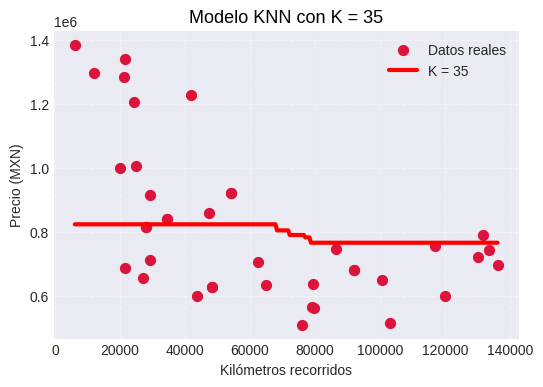

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


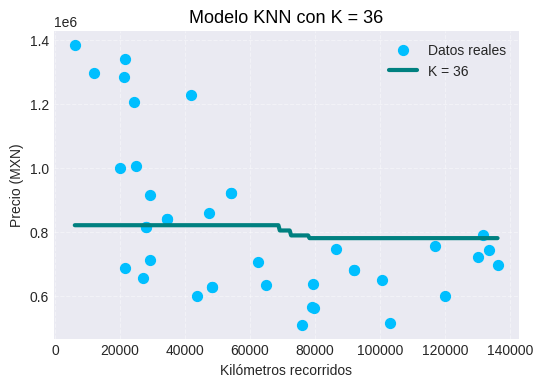

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


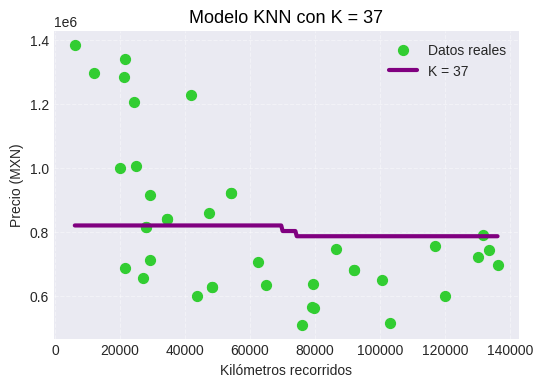

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


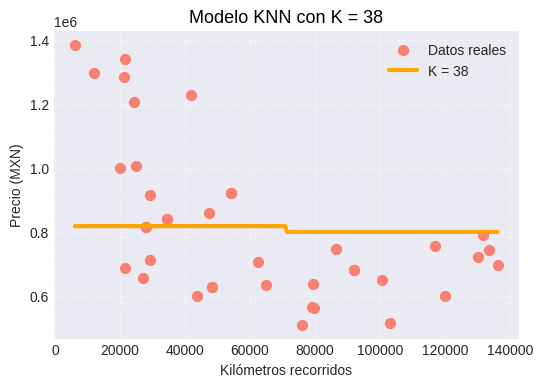

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


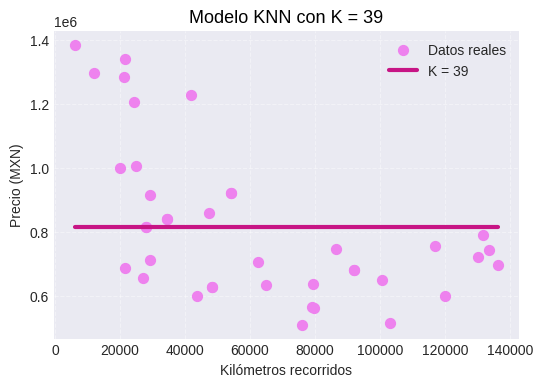

In [ ]:
# Generar 39 gráficas del modelo KNN con colores variados
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

# Crear un rango continuo de kilómetros para predecir
kms_rango = np.linspace(X["kms"].min(), X["kms"].max(), 300).reshape(-1, 1)

# Número máximo de vecinos igual al total de registros
max_num_vecinos = len(carros)

# Paletas de colores personalizadas
colores_puntos = [
    "royalblue", "darkorange", "mediumseagreen", "orchid", "gold",
    "crimson", "deepskyblue", "limegreen", "salmon", "violet"
]
colores_linea = [
    "deeppink", "dodgerblue", "lime", "darkmagenta", "goldenrod",
    "red", "teal", "purple", "orange", "mediumvioletred"
]

# Generar todas las gráficas
for num_vecinos in range(1, max_num_vecinos + 1):
    # Seleccionar colores según el índice actual (cíclico)
    color_p = colores_puntos[num_vecinos % len(colores_puntos)]
    color_l = colores_linea[num_vecinos % len(colores_linea)]

    # Crear y entrenar el modelo
    knn = KNeighborsRegressor(n_neighbors=num_vecinos)
    knn.fit(scaler_x.transform(X), scaler_y.transform(y.values.reshape(-1, 1)))

    # Predicciones sobre el rango de kms
    kms_rango_scaled = scaler_x.transform(kms_rango)
    pred_scaled = knn.predict(kms_rango_scaled)
    pred = scaler_y.inverse_transform(pred_scaled)

    # Crear gráfica
    plt.figure(figsize=(6,4))
    plt.scatter(X, y, color=color_p, s=50, label="Datos reales")
    plt.plot(kms_rango, pred, color=color_l, linewidth=3, label=f"K = {num_vecinos}")

    plt.title(f"Modelo KNN con K = {num_vecinos}", fontsize=13, color="black")
    plt.xlabel("Kilómetros recorridos")
    plt.ylabel("Precio (MXN)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

## Calculo de Error Cuadrático Medio

In [ ]:
# Importar la función para calcular el error cuadrático medio
from sklearn.metrics import mean_squared_error

# Arreglo para guardar los errores
errores_mse = []

for num_vecinos in range(1, max_num_vecinos + 1):
    # Crear y entrenar el modelo KNN
    knn = KNeighborsRegressor(n_neighbors=num_vecinos)
    knn.fit(scaler_x.transform(X), scaler_y.transform(y.values.reshape(-1, 1)))

    # Predicciones sobre los datos originales (para calcular el MSE)
    y_pred_scaled = knn.predict(scaler_x.transform(X))
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    # Calcular el Error Cuadrático Medio (MSE)
    mse = mean_squared_error(y, y_pred)

    # Guardar el MSE en la lista
    errores_mse.append(mse)

Errores cuadráticos medios para cada K:
K = 1: MSE = 0.0000
K = 2: MSE = 15878635998.1026
K = 3: MSE = 16567592153.8860
K = 4: MSE = 19494376984.6282
K = 5: MSE = 22106923529.5733
K = 6: MSE = 20754790546.7593
K = 7: MSE = 23950447302.6201
K = 8: MSE = 26124640789.6526
K = 9: MSE = 26290614297.1656
K = 10: MSE = 28002675089.0490
K = 11: MSE = 29101154067.7656
K = 12: MSE = 30064570805.1948
K = 13: MSE = 31438507637.0630
K = 14: MSE = 32528586611.8791
K = 15: MSE = 32229281872.4445
K = 16: MSE = 31000124802.4988
K = 17: MSE = 32180252676.3634
K = 18: MSE = 33468177578.5663
K = 19: MSE = 35482090337.3397
K = 20: MSE = 36532807850.8022
K = 21: MSE = 37313244939.7352
K = 22: MSE = 36942428390.4733
K = 23: MSE = 37396028815.1459
K = 24: MSE = 38161123881.6309
K = 25: MSE = 38634694271.4811
K = 26: MSE = 39537715642.3310
K = 27: MSE = 40706939853.9695
K = 28: MSE = 42588647298.9201
K = 29: MSE = 43704228067.8782
K = 30: MSE = 44362984386.0718
K = 31: MSE = 45308660884.0539
K = 32: MSE = 4633

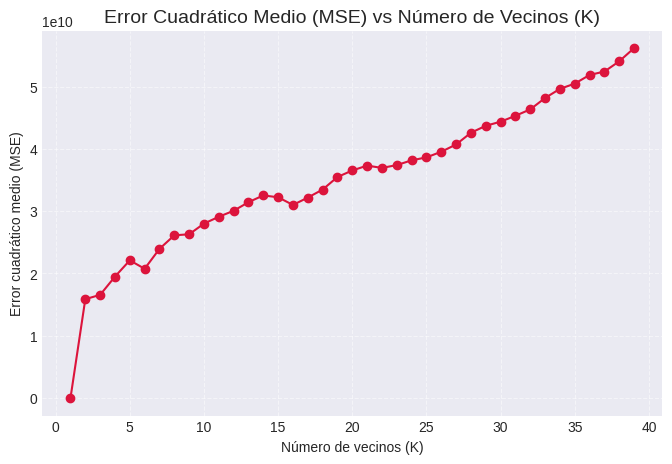

In [ ]:
# Mostrar el arreglo de errores
print("Errores cuadráticos medios para cada K:")
for k, error in enumerate(errores_mse, start=1):
    print(f"K = {k}: MSE = {error:.4f}")

# Graficar el error cuadrático medio vs número de vecinos
plt.figure(figsize=(8,5))
plt.plot(range(1, max_num_vecinos + 1), errores_mse, marker='o', linestyle='-', color='crimson')
plt.title("Error Cuadrático Medio (MSE) vs Número de Vecinos (K)", fontsize=14)
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Error cuadrático medio (MSE)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()